In [ ]:
import sys
import os

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_6/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Неделя 6. Методы декомпозиции: классическая, STL, MSTL

Декомпозиция раскладывает ряд на тренд, сезонность и остаток. Разложение не
единственно: это результат работы сглаживателя, и при другом окне получится другой тренд.

Разбираем три метода; каждый следующий исправляет недостаток предыдущего:
- **классическая** — скользящее среднее и средние по сезону;
- **STL** — сезонность может меняться, нет NaN на краях, есть устойчивость к выбросам;
- **MSTL** — несколько сезонностей сразу.

Для каждого метода: идея → гиперпараметры → разложение реального ряда.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsforecast.feature_engineering import mstl_decomposition
from statsforecast.models import MSTL as SFMSTL
from statsmodels.datasets import elec_equip
from statsmodels.graphics.tsaplots import month_plot, plot_acf
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.filters.filtertools import convolution_filter
from statsmodels.tsa.seasonal import MSTL, STL, seasonal_decompose
from statsmodels.tsa.tsatools import freq_to_period

warnings.simplefilter("ignore")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [2]:
def plot_decomps(results, title=None, figsize=(12, 7)):
    """Наложить несколько разложений statsmodels на одну фигуру."""
    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)
    axes[0].plot(next(iter(results.values())).observed, color="black", lw=1)
    axes[0].set_ylabel("observed")
    for name, res in results.items():
        for ax, comp in zip(axes[1:], ["trend", "seasonal", "resid"]):
            ax.plot(getattr(res, comp), lw=1, label=name)
            ax.set_ylabel(comp)
    axes[1].legend(loc="upper left")
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig

## Данные

- **AirPassengers** — месячный, мультипликативная сезонность.
- **elec_equip** — месячный индекс производства электрооборудования (еврозона), есть резкие провалы.
- **PJME** — почасовая нагрузка энергосистемы, сезонности 24 / 168 / 8766 часов.
  В исходнике есть 4 дубля и 30 пропущенных часов (перевод часов), STL не принимает NaN.
- **Синтетика** — ряд с известными компонентами: можно измерить ошибку разложения.

In [3]:
air = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_6/data/air_passengers.csv", index_col="Month", parse_dates=True)["#Passengers"].asfreq("MS")
log_air = np.log(air)

elec = elec_equip.load().data.iloc[:, 0].asfreq("MS")

pjme = (
    pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_6/data/PJME_hourly.csv.gz", parse_dates=["Datetime"])
    .groupby("Datetime")["PJME_MW"].mean()  # дубли
    .asfreq("h")
    .interpolate()  # пропуски
    .loc["2015-08-03":"2018-08-02"]  # последние 3 года
)
len(air), len(elec), len(pjme)

(144, 257, 26304)

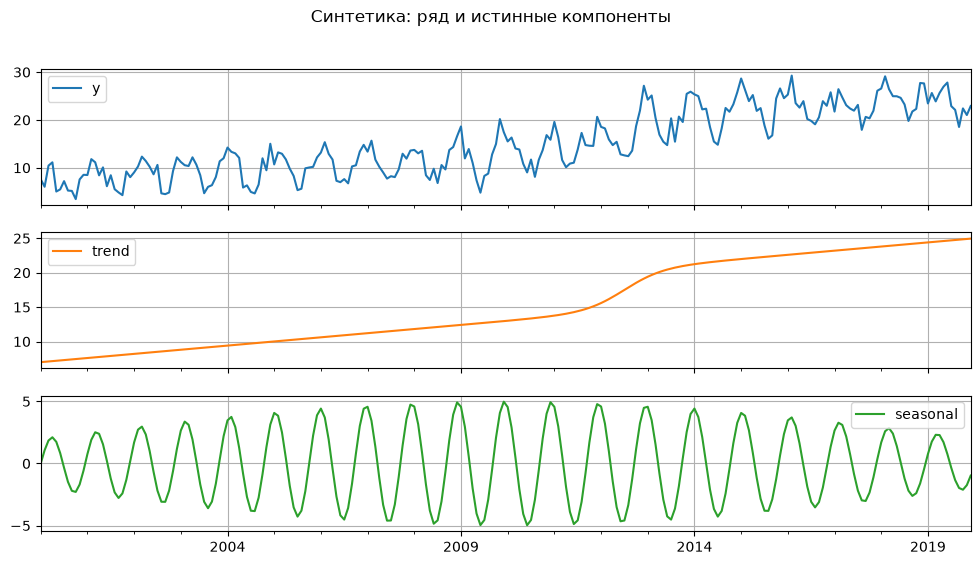

In [4]:
def make_synthetic(n=240, outlier=None, seed=42):
    """Тренд с изломом + сезонность с меняющимися амплитудой и фазой + шум."""
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    trend = 10 + 0.05 * t + 3 * np.tanh((t - 150) / 10)
    drift = np.sin(np.pi * t / n)  # 0 → 1 → 0
    seasonal = (2 + 3 * drift) * np.sin(2 * np.pi * t / 12 + 2 * drift)
    y = trend + seasonal + rng.normal(0, 2, n)
    df = pd.DataFrame(
        {"y": y, "trend": trend, "seasonal": seasonal},
        index=pd.date_range("2000-01", periods=n, freq="MS"),
    )
    if outlier is not None:
        df.loc[outlier, "y"] += 40
    return df


synth = make_synthetic()
synth.plot(subplots=True, figsize=(12, 6), title="Синтетика: ряд и истинные компоненты");

## 1. Что такое декомпозиция

- Аддитивная: $y_t = T_t + S_t + R_t$.
- Мультипликативная: $y_t = T_t \cdot S_t \cdot R_t$; после $\log$ становится аддитивной.

Сезонность — паттерн с **известным** периодом $m$. Его берут из частоты данных
или по пикам ACF.

period по частоте: 12


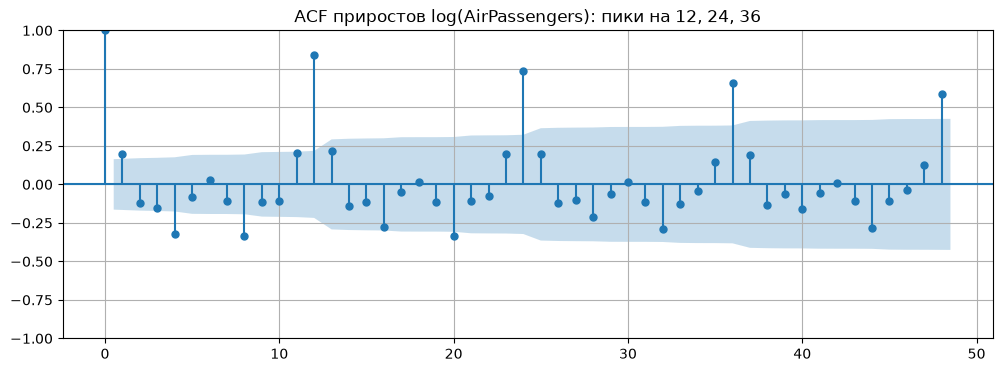

In [5]:
print("period по частоте:", freq_to_period(air.index.freq))
plot_acf(log_air.diff().dropna(), lags=48, title="ACF приростов log(AirPassengers): пики на 12, 24, 36");

## 2. Классическая декомпозиция — `seasonal_decompose`

### Идея

1. **Тренд** — центрированное скользящее среднее. Для чётного $m$ это $2\times m$-MA
   с весами $[\tfrac12, 1, \dots, 1, \tfrac12]/m$: окно центрировано, каждый месяц входит с одинаковым весом.
2. **Сезонность** — среднее детрендированного ряда по каждой фазе (все январи, все февраля, ...),
   центрированное к нулю.
3. **Остаток** — $y - T - S$.

Повторим шаги средствами statsmodels и сверим с `seasonal_decompose`.

In [6]:
m = 12
trend = convolution_filter(log_air, np.r_[0.5, np.ones(m - 1), 0.5] / m)
detrended = log_air - trend
profile = detrended.groupby(detrended.index.month).mean()
profile -= profile.mean()
seasonal = pd.Series(profile.loc[log_air.index.month].values, index=log_air.index)
resid = log_air - trend - seasonal

res_classic = seasonal_decompose(log_air, period=m)
print("trend совпадает:   ", np.allclose(trend, res_classic.trend, equal_nan=True))
print("seasonal совпадает:", np.allclose(seasonal, res_classic.seasonal))
print("resid совпадает:   ", np.allclose(resid, res_classic.resid, equal_nan=True))

trend совпадает:    True
seasonal совпадает: True
resid совпадает:    True



Сезонная компонента — это всего $m$ чисел, повторённых по кругу:

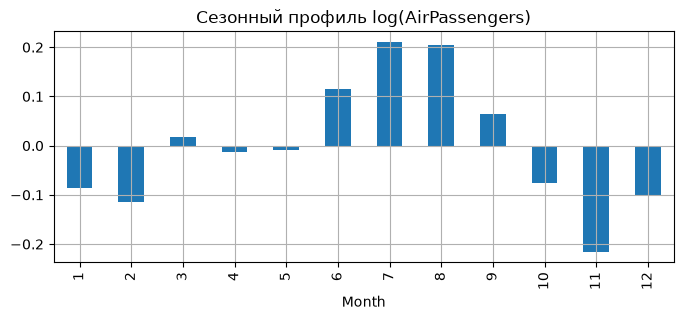

In [7]:
profile.plot.bar(title="Сезонный профиль log(AirPassengers)", figsize=(8, 3));

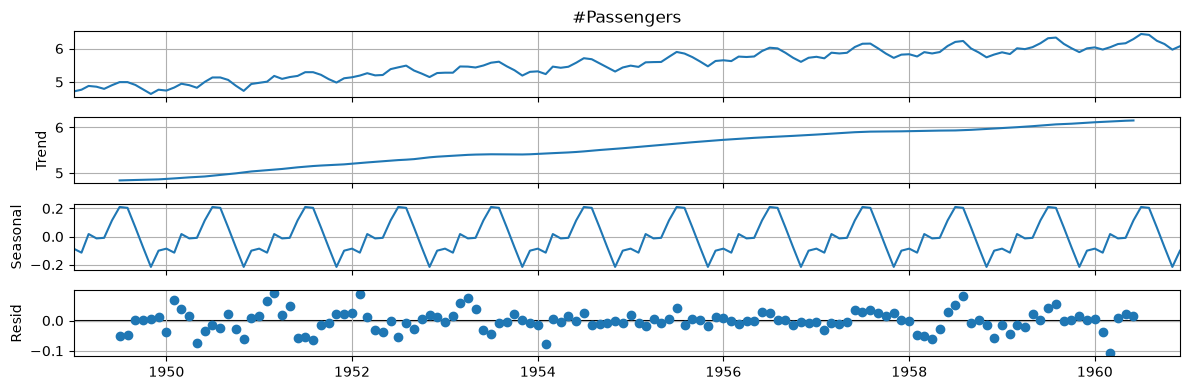

In [8]:
res_classic.plot();

### Гиперпараметры

**`model`.** Аддитивная модель на исходном ряде оставляет в остатке «воронку»:
амплитуда сезонности растёт вместе с уровнем. Мультипликативная её убирает
(и эквивалентна аддитивной на $\log y$).

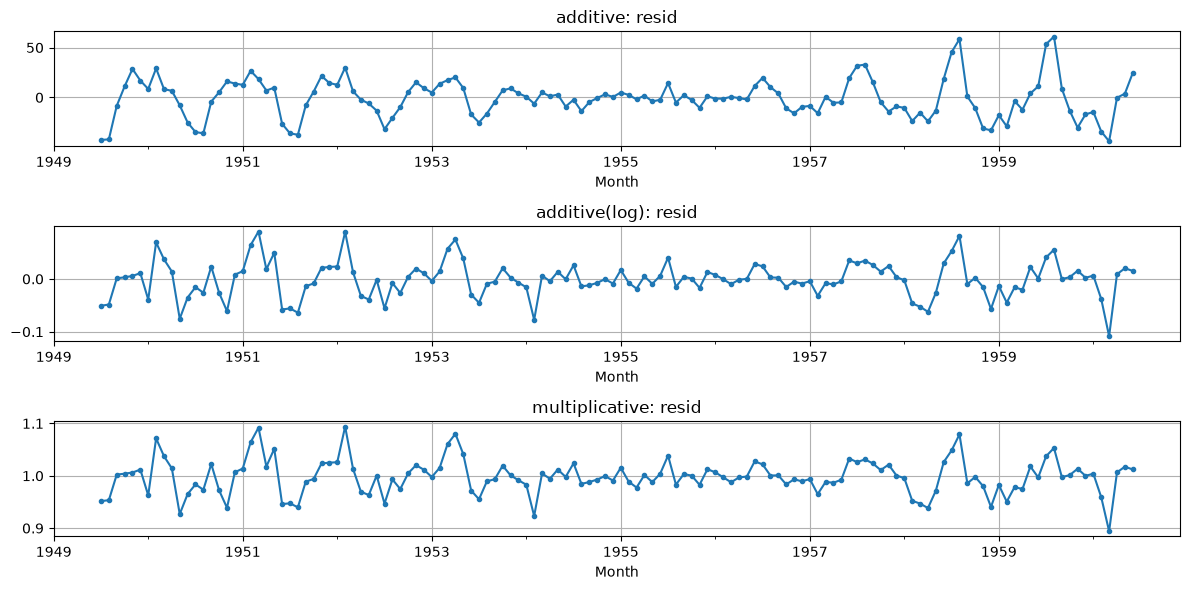

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))
seasonal_decompose(air, model="additive").resid.plot(ax=axes[0], title="additive: resid", marker=".")
seasonal_decompose(log_air, model="additive").resid.plot(ax=axes[1], title="additive(log): resid", marker=".")
seasonal_decompose(air, model="multiplicative").resid.plot(ax=axes[2], title="multiplicative: resid", marker=".")
fig.tight_layout()

**`period`.** Неверный период — сезонность усредняется по «чужим» фазам и
вырождается, а настоящий цикл уходит в остаток.

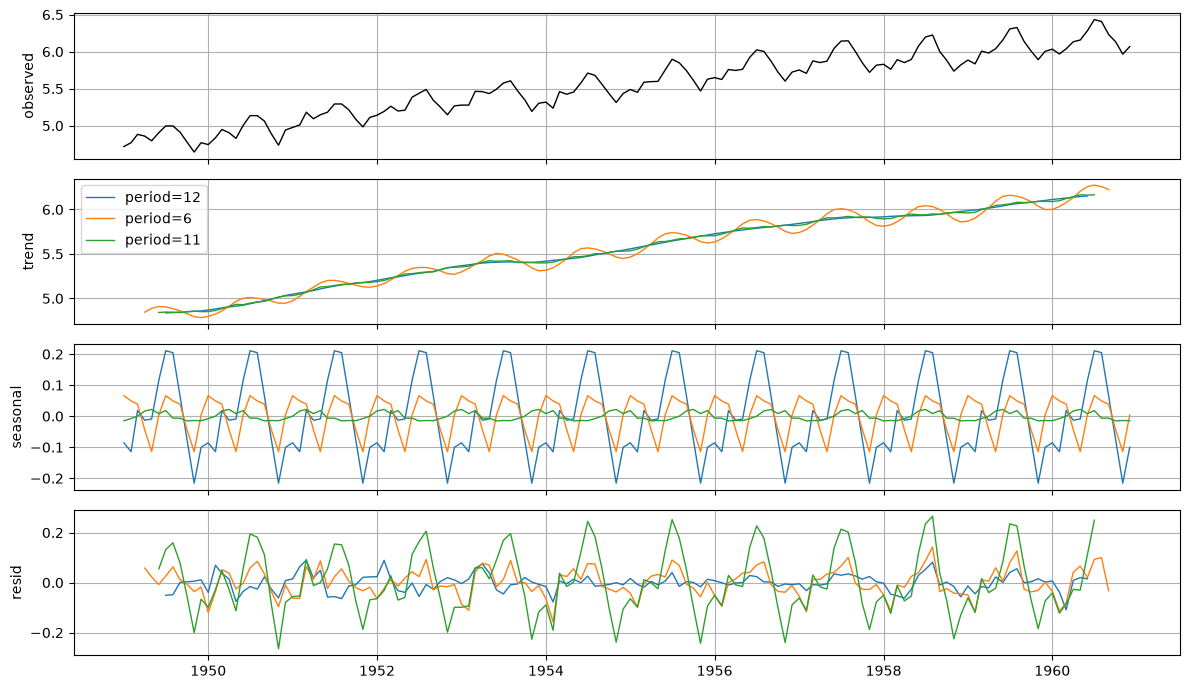

In [10]:
plot_decomps({f"period={p}": seasonal_decompose(log_air, period=p) for p in [12, 6, 11]});

**`filt`.** Свои веса фильтра тренда. Окно $2\times 24$ даёт более гладкий тренд,
но NaN на краях становится вдвое больше.

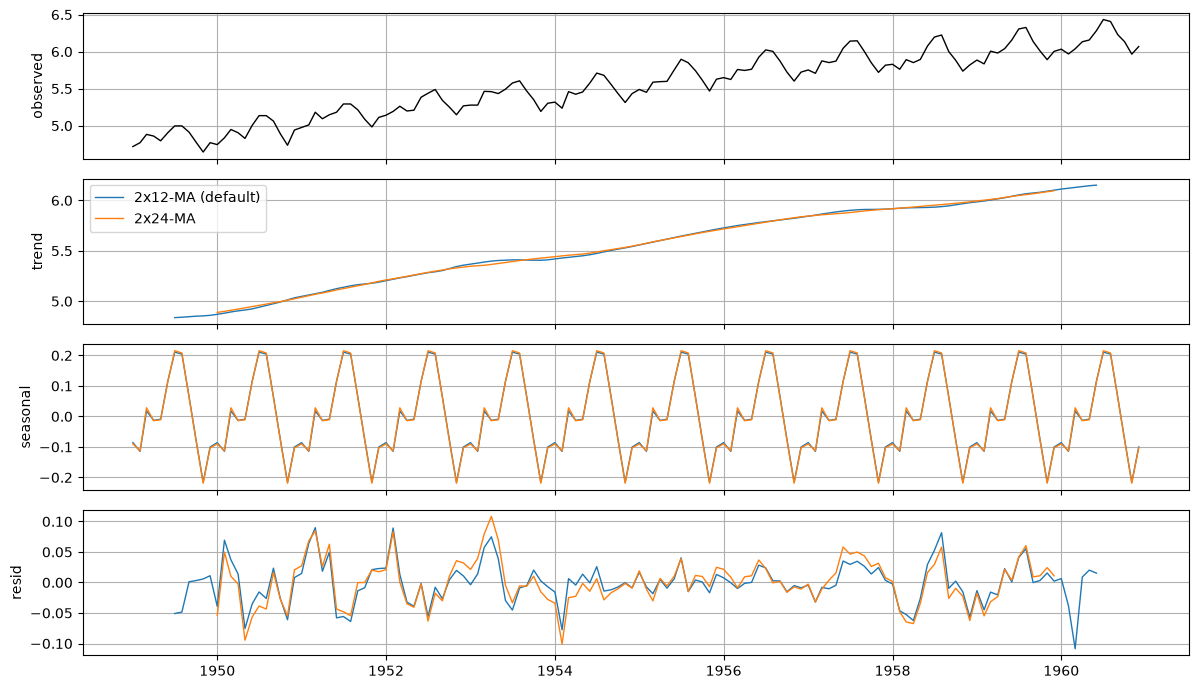

In [11]:
filt_24 = np.r_[0.5, np.ones(23), 0.5] / 24
plot_decomps({
    "2x12-MA (default)": res_classic,
    "2x24-MA": seasonal_decompose(log_air, period=12, filt=filt_24),
});

**`two_sided=False`.** Фильтр только по прошлым значениям: тренд запаздывает
примерно на $m/2$ шагов, и это запаздывание искажает сезонность.

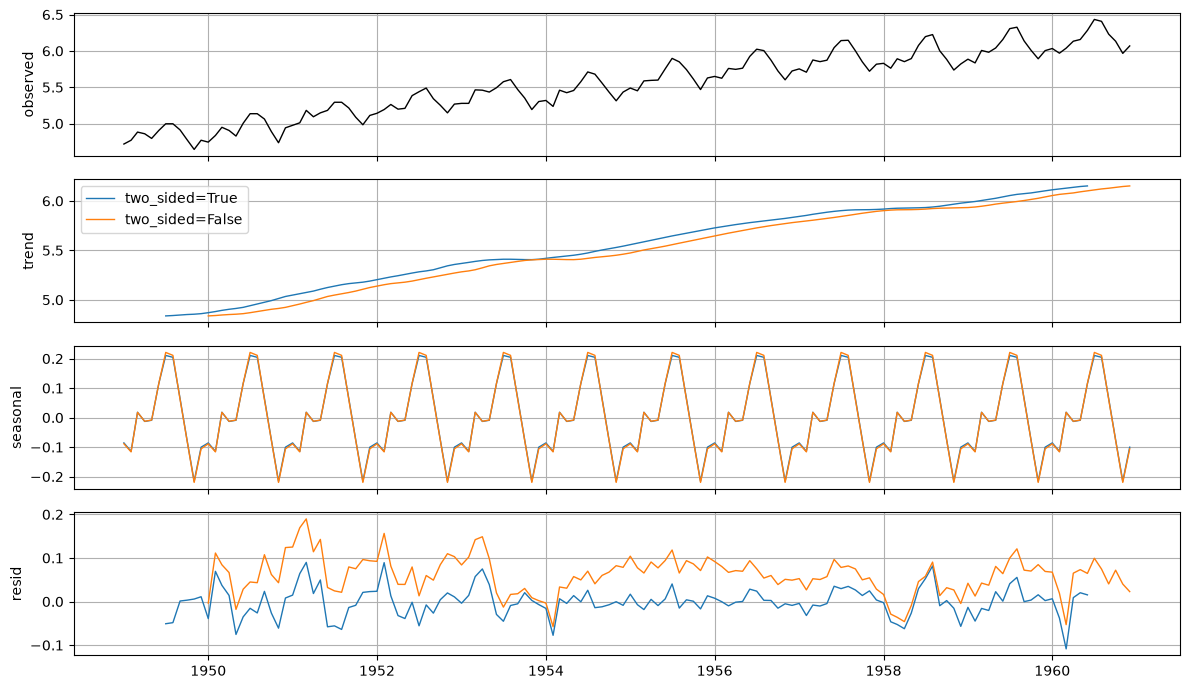

In [12]:
plot_decomps({
    "two_sided=True": res_classic,
    "two_sided=False": seasonal_decompose(log_air, period=12, two_sided=False),
});

**`extrapolate_trend`.** По умолчанию на краях $m/2$ значений NaN. `"freq"`
достраивает тренд линейной регрессией по ближайшему периоду.

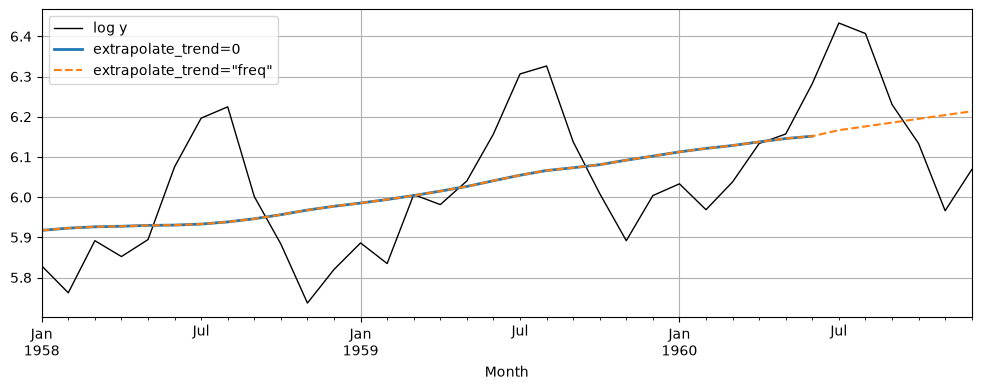

In [13]:
ax = log_air["1958":].plot(color="black", lw=1, label="log y")
res_classic.trend["1958":].plot(ax=ax, lw=2, label="extrapolate_trend=0")
seasonal_decompose(log_air, period=12, extrapolate_trend="freq").trend["1958":].plot(
    ax=ax, ls="--", label='extrapolate_trend="freq"'
)
ax.legend();

### Ограничения

**Сезонность не меняется.** Проверим на синтетике: у истинной сезонности
амплитуда растёт и фаза сдвигается. `month_plot` рисует каждый месяц по годам —
у классики это горизонтальные линии, вся эволюция уходит в остаток.

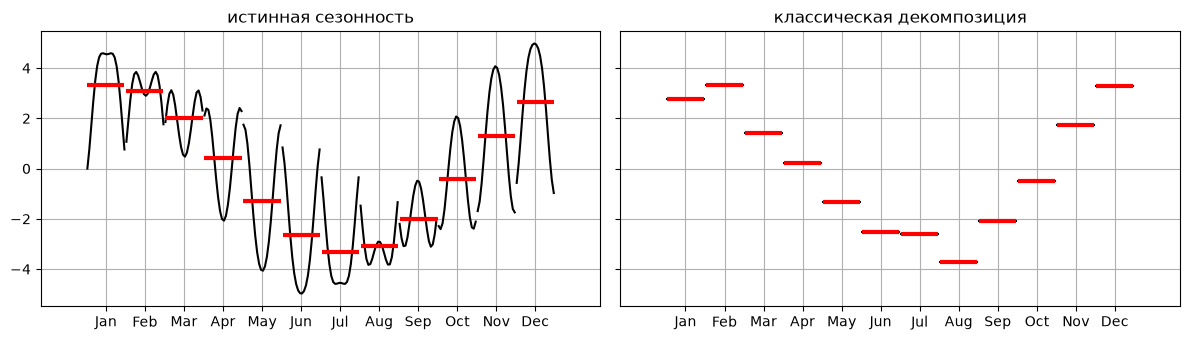

In [14]:
res_synth = seasonal_decompose(synth["y"], period=12)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
month_plot(synth["seasonal"].to_period("M"), ax=axes[0])
axes[0].set_title("истинная сезонность")
month_plot(res_synth.seasonal.to_period("M"), ax=axes[1])
axes[1].set_title("классическая декомпозиция")
fig.tight_layout()

**Нет устойчивости к выбросам.** Добавим один выброс +40 в марте 2010.
Мартовская сезонность сдвигается **во всех годах**, тренд получает горб шириной $m$.

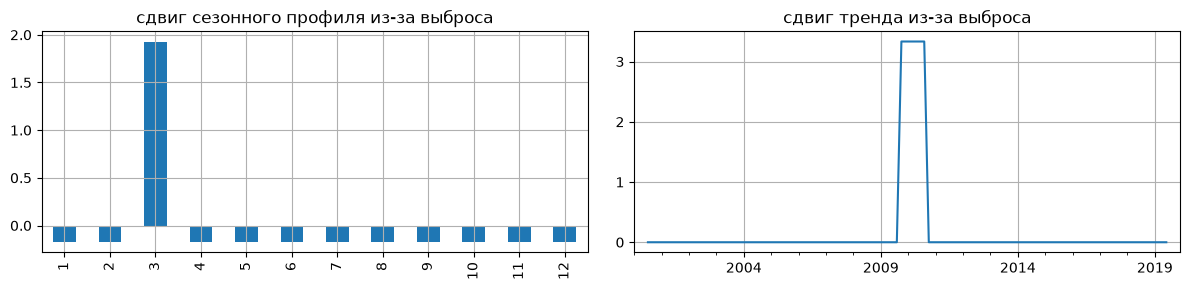

In [15]:
synth_out = make_synthetic(outlier="2010-03-01")
res_out = seasonal_decompose(synth_out["y"], period=12)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
(res_out.seasonal - res_synth.seasonal)[:12].set_axis(range(1, 13)).plot.bar(
    ax=axes[0], title="сдвиг сезонного профиля из-за выброса"
)
(res_out.trend - res_synth.trend).plot(ax=axes[1], title="сдвиг тренда из-за выброса")
fig.tight_layout()

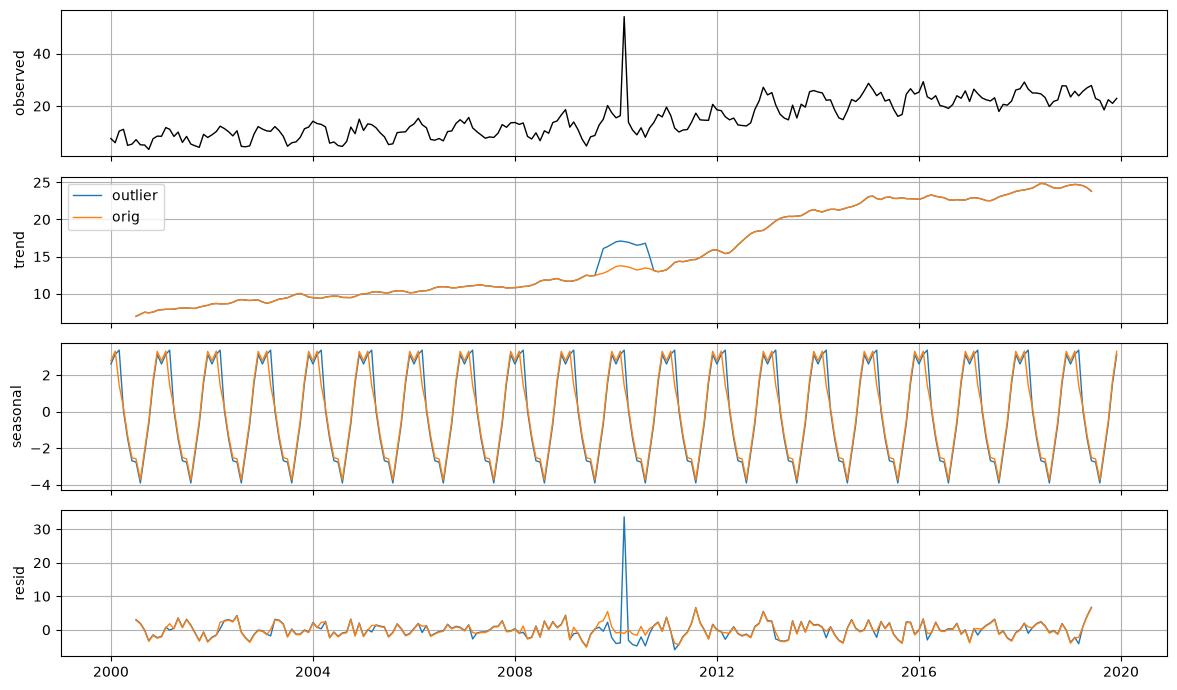

In [16]:
plot_decomps({
    "outlier": res_out,
    "orig": res_synth,
});

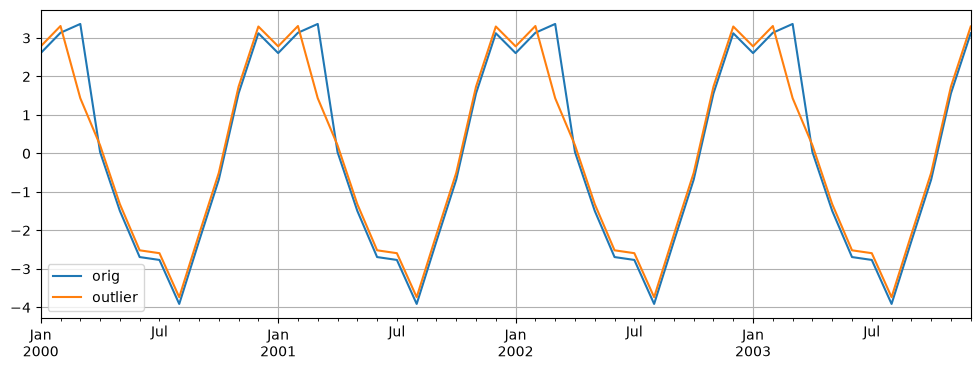

In [17]:
res_out.seasonal[:48].plot(label="orig")
res_synth.seasonal[:48].plot(label="outlier")
plt.legend()

Итого: NaN на краях, постоянная сезонность, чувствительность к выбросам. STL решает все три проблемы.

## 3. STL — `STL`

### Строительный блок: LOESS

LOESS — локальная регрессия: в каждой точке строится взвешенная регрессия
(степень 0 или 1) по соседям в окне, веса убывают с расстоянием (tricube).
Главный гиперпараметр — ширина окна: маленькое повторяет шум, большое пересглаживает.

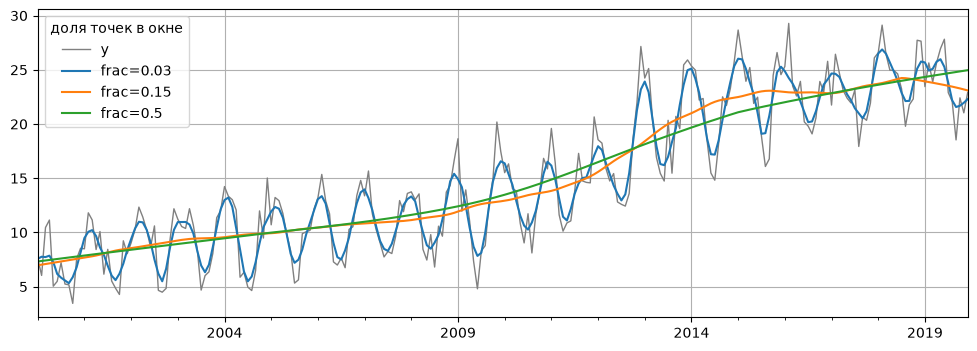

In [18]:
t = np.arange(len(synth))
ax = synth["y"].plot(color="gray", lw=1, label="y")
for frac in [0.03, 0.15, 0.5]:
    pd.Series(lowess(synth["y"], t, frac=frac, return_sorted=False), index=synth.index).plot(ax=ax, label=f"frac={frac}")
ax.legend(title="доля точек в окне");

### Идея

Все гиперпараметры STL — длины окон и степени LOESS для разных компонент.

**Внутренний цикл** (`inner_iter` раз):
1. Детрендирование: $y - T$.
2. Каждый подряд (все январи, все февраля, ...) сглаживается LOESS с окном `seasonal`.
   В классике подряд заменялся одним средним, здесь он может медленно меняться.
3. Low-pass фильтр (MA $m$ → MA $m$ → MA 3 → LOESS `low_pass`) вычитается из результата:
   убираем то, что относится к тренду. Получаем $S$.
4. Десезонализация $y - S$ и LOESS с окном `trend` → новый $T$.

**Внешний цикл** (`outer_iter` раз, только при `robust=True`): по остаткам
считаются веса; точки с большим остатком получают вес около 0, и внутренний цикл повторяется.

Сравним сезонность по подрядам с классикой:

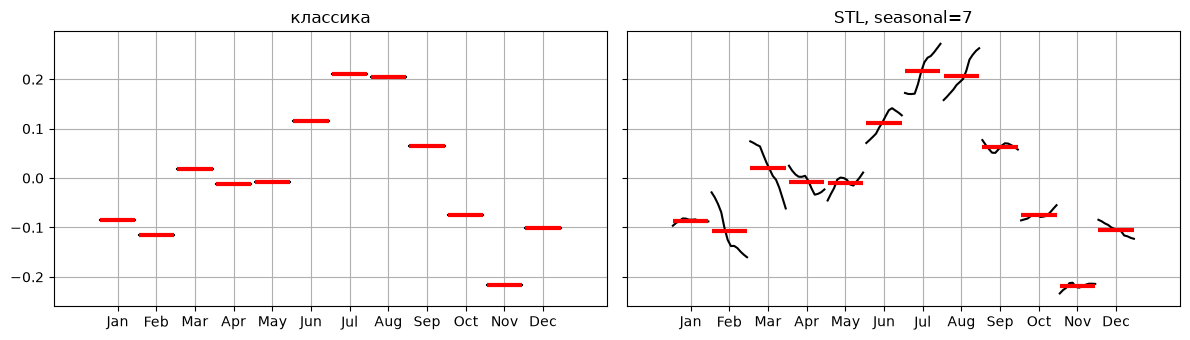

In [19]:
res_stl = STL(log_air, period=12).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
month_plot(res_classic.seasonal.to_period("M"), ax=axes[0])
axes[0].set_title("классика")
month_plot(res_stl.seasonal.to_period("M"), ax=axes[1])
axes[1].set_title("STL, seasonal=7")
fig.tight_layout()

### Гиперпараметры

**`seasonal`** — окно сглаживания подрядов (нечётное, ≥ 7). Маленькое: сезонность
гибкая, но забирает шум. Большое: сезонность почти постоянная.

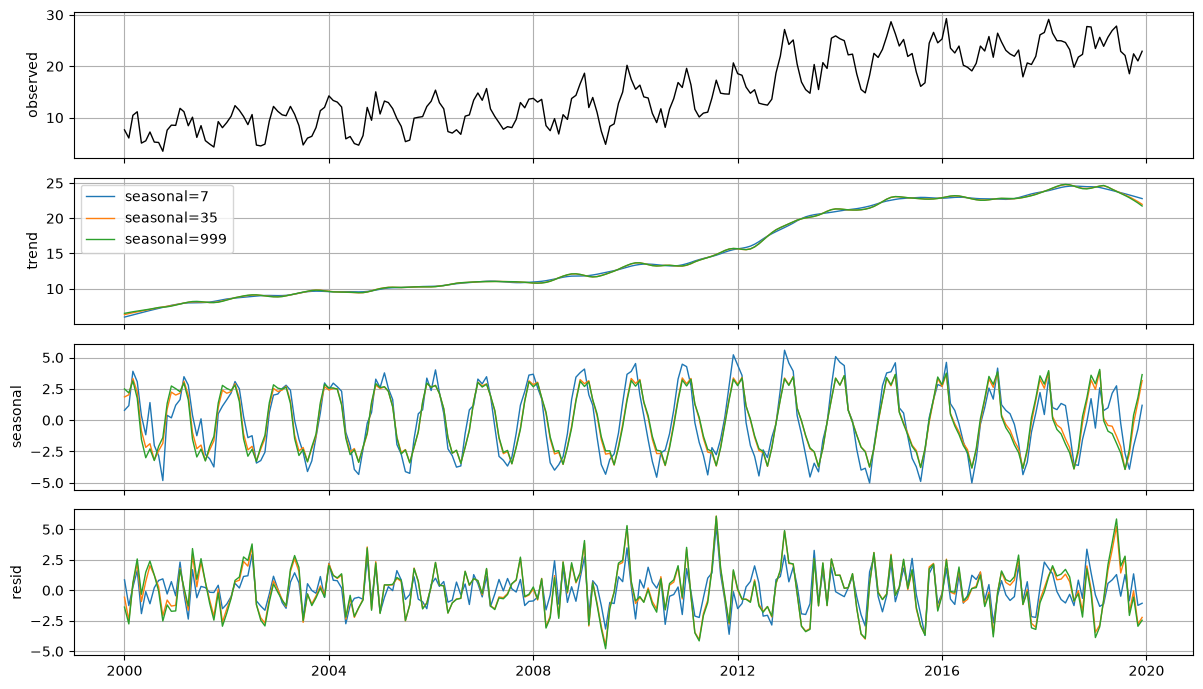

In [20]:
plot_decomps({f"seasonal={w}": STL(synth["y"], period=12, seasonal=w).fit() for w in [7, 35, 999]});

На синтетике можно измерить ошибку $\hat S$ против истинной. Слишком маленькое
окно ловит шум, большое не успевает за изменением сезонности и приходит к уровню классики.

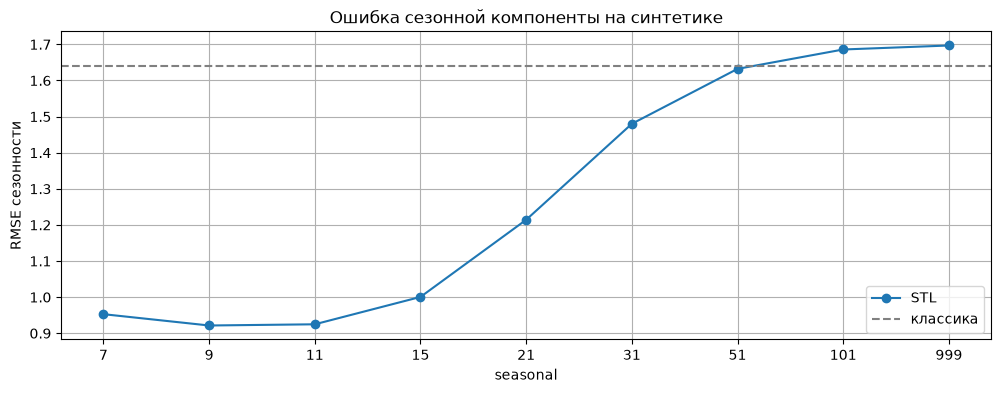

In [21]:
windows = [7, 9, 11, 15, 21, 31, 51, 101, 999]
rmse = [np.sqrt(((STL(synth["y"], period=12, seasonal=w).fit().seasonal - synth["seasonal"]) ** 2).mean()) for w in windows]
rmse_classic = np.sqrt(((res_synth.seasonal - synth["seasonal"]) ** 2).mean())

ax = pd.Series(rmse, index=[str(w) for w in windows]).plot(marker="o", label="STL")
ax.axhline(rmse_classic, color="gray", ls="--", label="классика")
ax.set(xlabel="seasonal", ylabel="RMSE сезонности", title="Ошибка сезонной компоненты на синтетике")
ax.legend();

При большом окне STL приближается к классике, но точно совпадает с ней только
при `seasonal_deg=0`. При `seasonal_deg=1` (по умолчанию) LOESS даже в
бесконечном окне подгоняет в каждом подряде **прямую** — линейно меняющуюся сезонность:

In [22]:
for deg in [0, 1]:
    s = STL(log_air, period=12, seasonal=999, seasonal_deg=deg).fit().seasonal
    print(f"seasonal_deg={deg}: max |S_STL - S_classic| =", (s - res_classic.seasonal).abs().max().round(4))
print("размах сезонности:", (res_classic.seasonal.max() - res_classic.seasonal.min()).round(4))

seasonal_deg=0: max |S_STL - S_classic| = 0.0047
seasonal_deg=1: max |S_STL - S_classic| = 0.0764
размах сезонности: 0.4267


**`trend`** — окно тренда. По умолчанию — наименьшее нечётное
$\ge 1.5m / (1 - 1.5/\text{seasonal})$; все итоговые значения окон видны в `.config`.
Чем больше окно, тем жёстче тренд: излом уходит в остаток.

{'period': 12, 'seasonal': 7, 'seasonal_deg': 1, 'seasonal_jump': 1, 'trend': 23, 'trend_deg': 1, 'trend_jump': 1, 'low_pass': 13, 'low_pass_deg': 1, 'low_pass_jump': 1, 'robust': False}


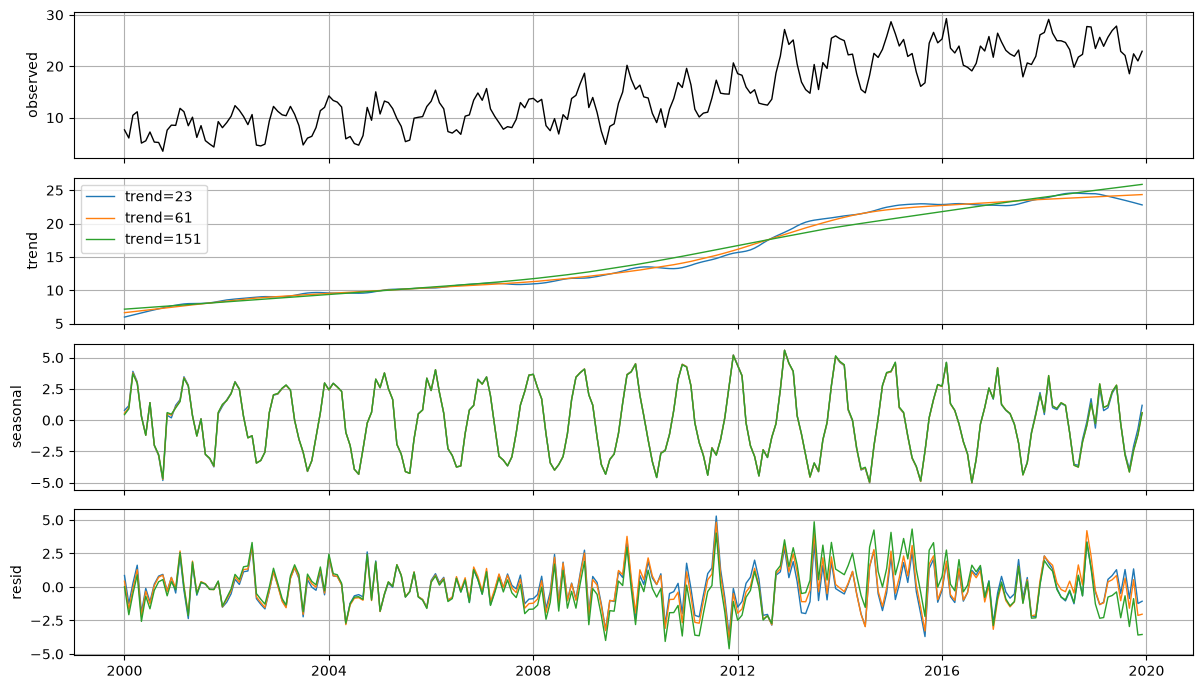

In [23]:
print(STL(synth["y"], period=12).config)
plot_decomps({f"trend={w}": STL(synth["y"], period=12, trend=w).fit() for w in [23, 61, 151]});

**`robust`** — внешний цикл с весами. Без него провалы elec_equip размазываются
по тренду и сезонности, с ним остаются в остатке.

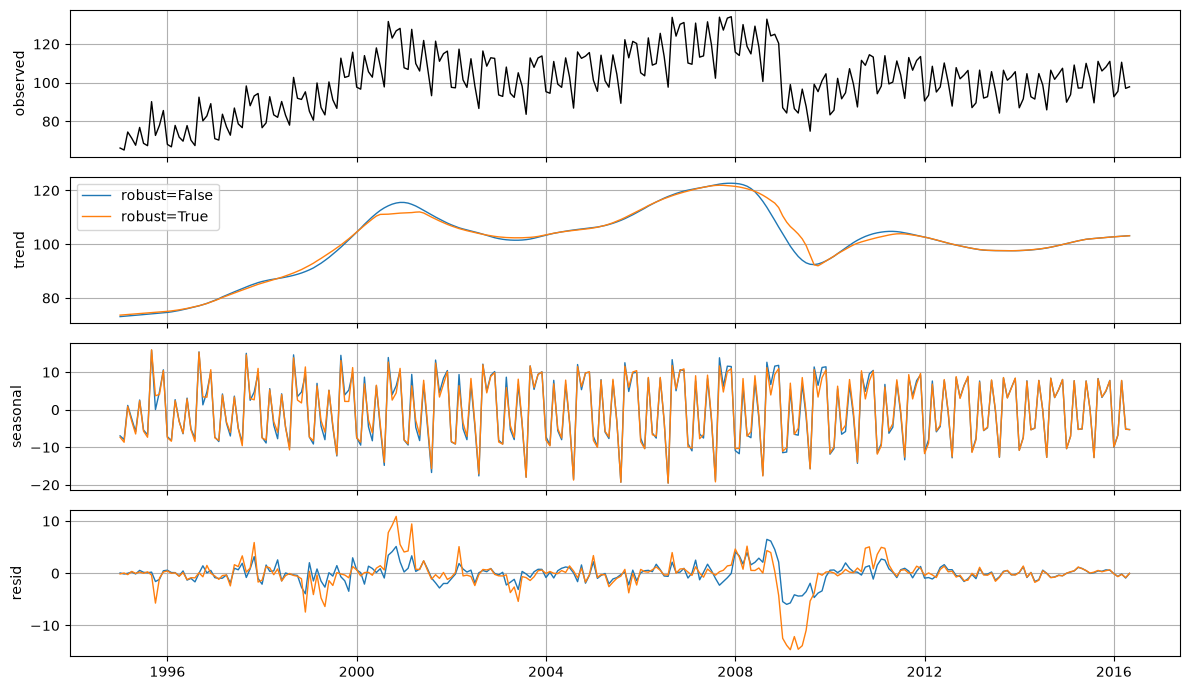

In [24]:
res_elec = STL(elec, period=12, robust=True).fit()
plot_decomps({
    "robust=False": STL(elec, period=12).fit(),
    "robust=True": res_elec,
});

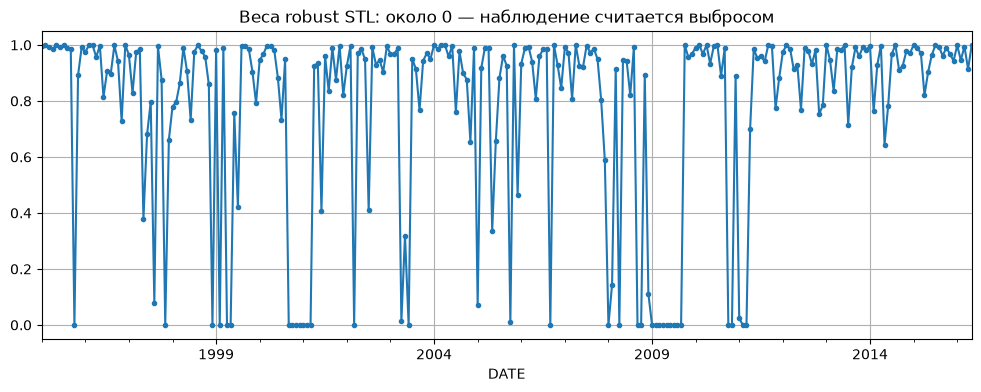

In [25]:
res_elec.weights.plot(title="Веса robust STL: около 0 — наблюдение считается выбросом", marker=".");

**`seasonal_deg`, `trend_deg`** — степень LOESS (0 — локальная константа, 1 — локальная прямая).
На реальных рядах обычно влияет слабо.

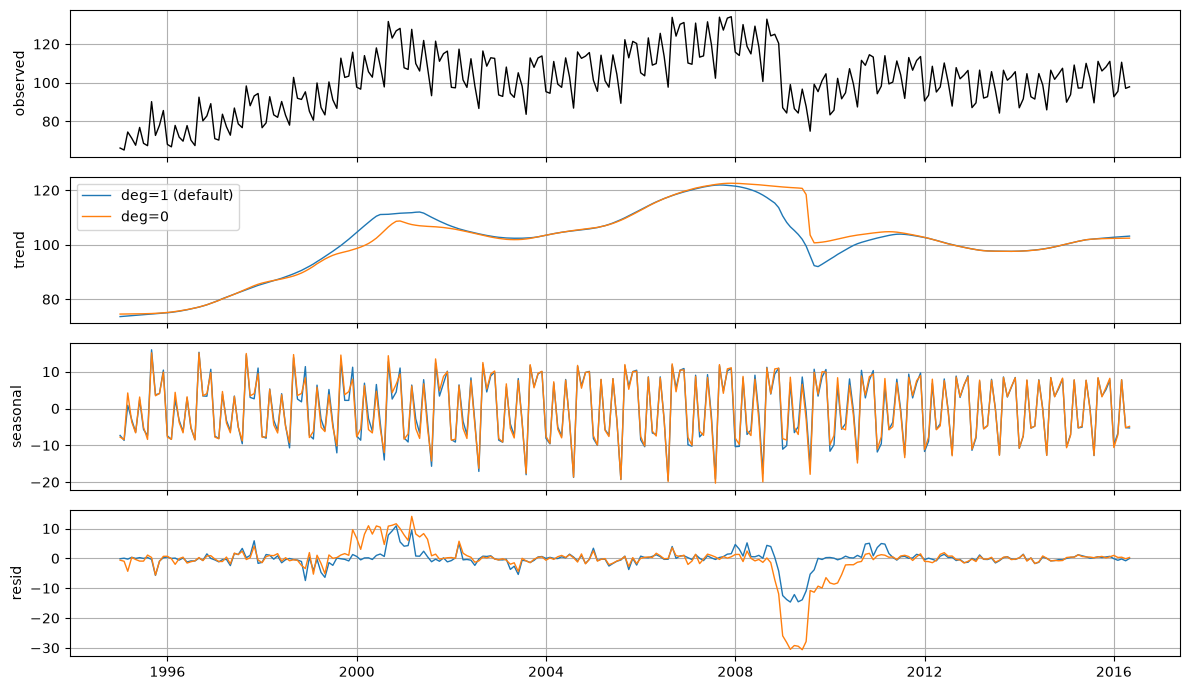

In [26]:
plot_decomps({
    "deg=1 (default)": res_elec,
    "deg=0": STL(elec, period=12, robust=True, seasonal_deg=0, trend_deg=0).fit(),
});

**`seasonal_jump`, `trend_jump`, `low_pass_jump`** — LOESS считается в каждой
`jump`-й точке, между ними линейная интерполяция. Разумный `jump` — 10–20% от
соответствующего окна. На 3 годах PJME с `period=168` окна тренда и low-pass —
321 и 169 точек, а `seasonal=7`, поэтому `seasonal_jump` не трогаем:

In [27]:
rows, base = [], None
for jump in [1, 5, 25]:
    start = time.perf_counter()
    r = STL(pjme, period=168, trend_jump=jump, low_pass_jump=jump).fit()
    elapsed = time.perf_counter() - start
    base = r if base is None else base
    rows.append({
        "jump": jump,
        "время, с": elapsed,
        "RMSE(ΔS) / std(S)": np.sqrt(((r.seasonal - base.seasonal) ** 2).mean()) / base.seasonal.std(),
        "RMSE(ΔT) / std(T)": np.sqrt(((r.trend - base.trend) ** 2).mean()) / base.trend.std(),
    })
pd.DataFrame(rows).set_index("jump").round(4)

,"время, с",RMSE(ΔS) / std(S),RMSE(ΔT) / std(T)
jump,,,
1,1.4432,0.0000,0.0000
5,0.2935,0.0000,0.0002
25,0.0737,0.0009,0.0043


Остальное:
- `low_pass` — окно low-pass фильтра, по умолчанию наименьшее нечётное $> m$; трогать почти не нужно.
- `inner_iter`, `outer_iter` — аргументы `.fit()`; по умолчанию 5/0 без `robust` и 2/15 с ним.

### Разложение реальных рядов

AirPassengers: STL на $\log y$ против классики — нет NaN на краях, сезонность меняется.

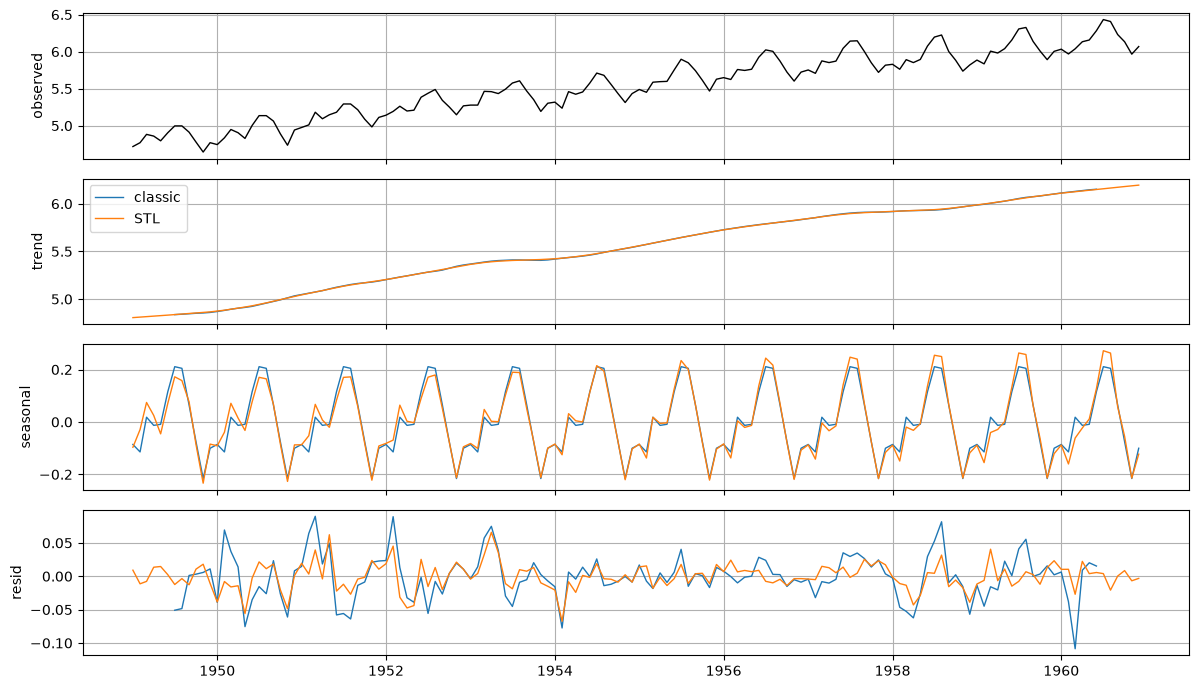

In [28]:
plot_decomps({"classic": res_classic, "STL": res_stl});

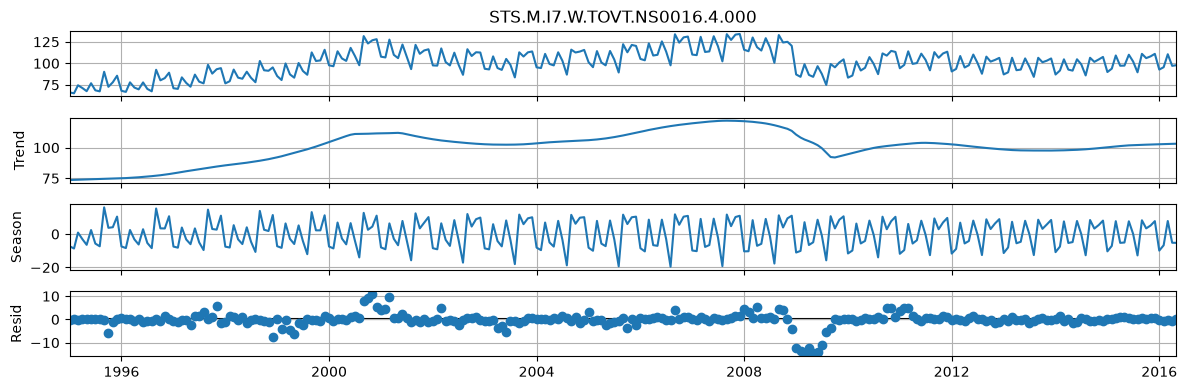

In [29]:
res_elec.plot();

## 4. MSTL — `MSTL`

### Зачем

У почасовой нагрузки есть дневной (24) и недельный (168) циклы. STL берёт один
период. С `period=24` недельный цикл попадает в тренд:

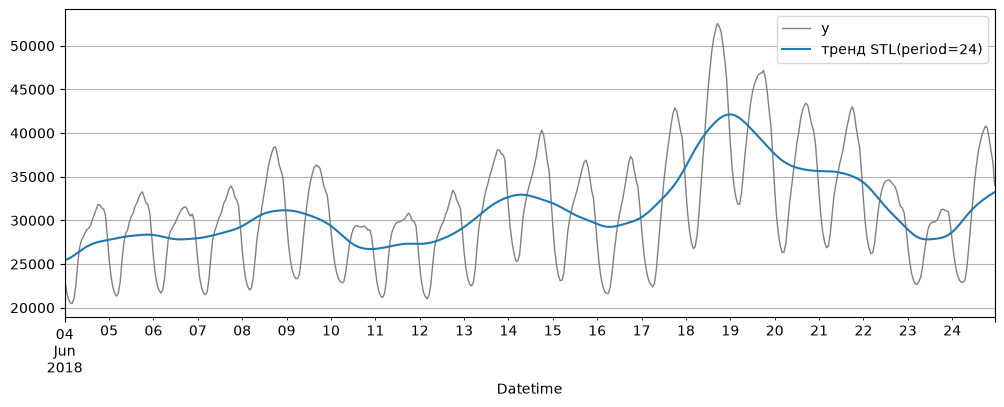

In [30]:
weeks = slice("2018-06-04", "2018-06-24")
ax = pjme[weeks].plot(color="gray", lw=1, label="y")
STL(pjme, period=24).fit().trend[weeks].plot(ax=ax, label="тренд STL(period=24)")
ax.legend();

С `period=168` оба цикла сливаются в одну компоненту, и каждый из 168 часов
недели оценивается по одной точке в неделю — данных на фазу в 7 раз меньше.

### Идея

1. Опционально Box-Cox (`lmbda`).
2. Периоды сортируются по возрастанию; STL с периодом $m_1$ → $S^{(1)}$, вычитаем;
   STL с $m_2$ на остатке → $S^{(2)}$ и т.д.
3. `iterate` раз: каждую $S^{(i)}$ возвращаем в ряд и переоцениваем STL с периодом $m_i$.
4. Тренд — из последнего STL, остаток $= y - T - \sum_i S^{(i)}$.

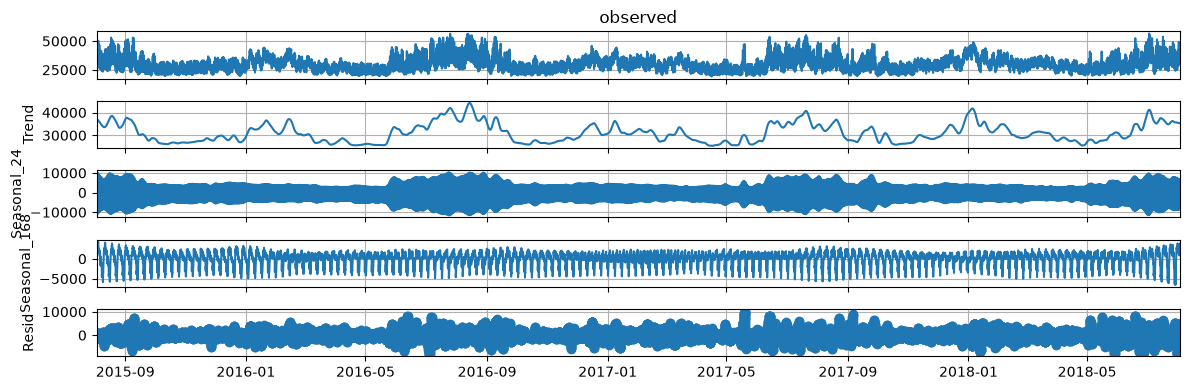

In [31]:
res_mstl = MSTL(pjme, periods=[24, 168]).fit()
res_mstl.plot();

### Гиперпараметры

**`periods`.** На 3 годах есть ещё годовая сезонность (8766 ч). Без неё лето/зима
сидят в тренде. Нужно не меньше двух полных периодов каждой длины.

STL с периодом 8766 медленный: окна тренда и low-pass — десятки тысяч точек
(около 2 минут). `trend_jump` и `low_pass_jump` через `stl_kwargs` сокращают
время до нескольких секунд; компоненты при этом меняются на 1–2% от своего std.

7.1 с


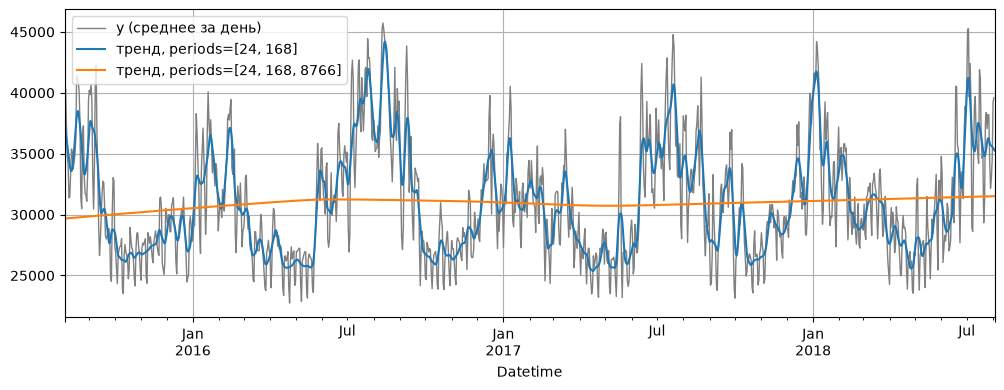

In [32]:
start = time.perf_counter()
res_mstl_y = MSTL(
    pjme, periods=[24, 168, 8766], stl_kwargs={"trend_jump": 20, "low_pass_jump": 20}
).fit()
print(f"{time.perf_counter() - start:.1f} с")

ax = pjme.resample("D").mean().plot(color="gray", lw=1, label="y (среднее за день)")
res_mstl.trend.plot(ax=ax, label="тренд, periods=[24, 168]")
res_mstl_y.trend.plot(ax=ax, label="тренд, periods=[24, 168, 8766]")
ax.legend();

Лето и зима ушли из тренда. Но за 3 года у каждого часа года всего 3 наблюдения,
поэтому годовая компонента забирает и погодные колебания (см. разложение ниже).

**`windows`** — окна `seasonal` для каждого периода. По умолчанию $7 + 4k$ (11, 15):
зимой у дневного профиля два пика (утро и вечер), летом — один днём (кондиционеры).
Большие окна делают сезонность почти постоянной, и профили сливаются.

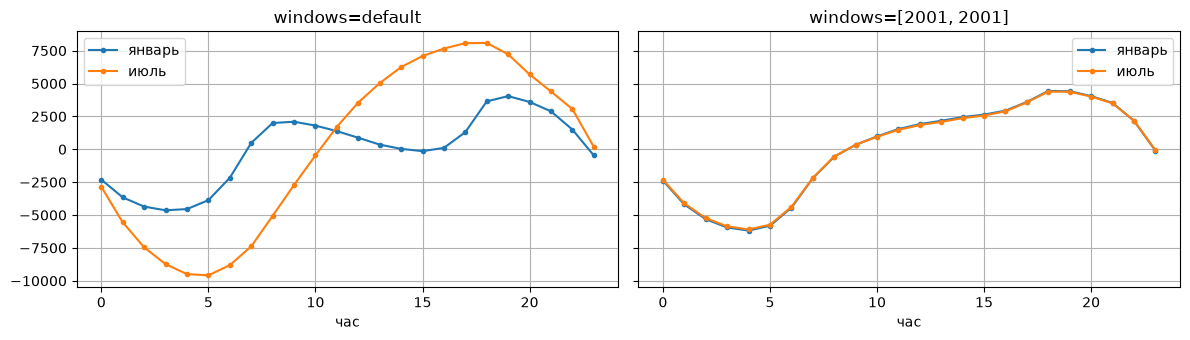

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for ax, w in zip(axes, [None, [2001, 2001]]):
    s24 = MSTL(pjme, periods=[24, 168], windows=w).fit().seasonal["seasonal_24"]
    for month, name in [(1, "январь"), (7, "июль")]:
        s = s24[s24.index.month == month]
        s.groupby(s.index.hour).mean().plot(ax=ax, marker=".", label=name)
    ax.set(title=f"windows={w or 'default'}", xlabel="час")
    ax.legend()
fig.tight_layout()

**`iterate`** — число уточнений. Изменения быстро затухают, по умолчанию 2.

In [34]:
ref = MSTL(pjme, periods=[24, 168], iterate=5).fit().seasonal
pd.DataFrame({
    it: np.sqrt(((MSTL(pjme, periods=[24, 168], iterate=it).fit().seasonal - ref) ** 2).mean())
    for it in [1, 2, 3]
}).T.rename_axis("iterate").round(1)

,seasonal_24,seasonal_168
iterate,,
1,88.3,81.5
2,27.5,26.3
3,16.3,16.1


**`lmbda`** — Box-Cox перед разложением (`"auto"` подбирает $\lambda$).
Без него амплитуда дневного цикла растёт вместе с уровнем нагрузки —
мультипликативный эффект в аддитивной модели.

In [35]:
rows = {}
for lmbda in [None, "auto"]:
    mstl = MSTL(pjme, periods=[24, 168], lmbda=lmbda)
    r = mstl.fit()
    amp = r.seasonal["seasonal_24"].resample("D").agg(lambda x: x.max() - x.min())
    rows[str(lmbda)] = {
        "λ": getattr(mstl, "est_lmbda", None),
        "corr(амплитуда за день, тренд)": np.corrcoef(amp, r.trend.resample("D").mean())[0, 1],
    }
pd.DataFrame(rows).T

,λ,"corr(амплитуда за день, тренд)"
None,NaN,0.717208
auto,-0.597203,0.077613


**`stl_kwargs`** — пробрасываются в каждый STL: `trend`, `robust`, `seasonal_deg`, `*_jump`
и т.д. Влияют так же, как в разделе 3.

### Разложение

Полное разложение с годовой сезонностью:

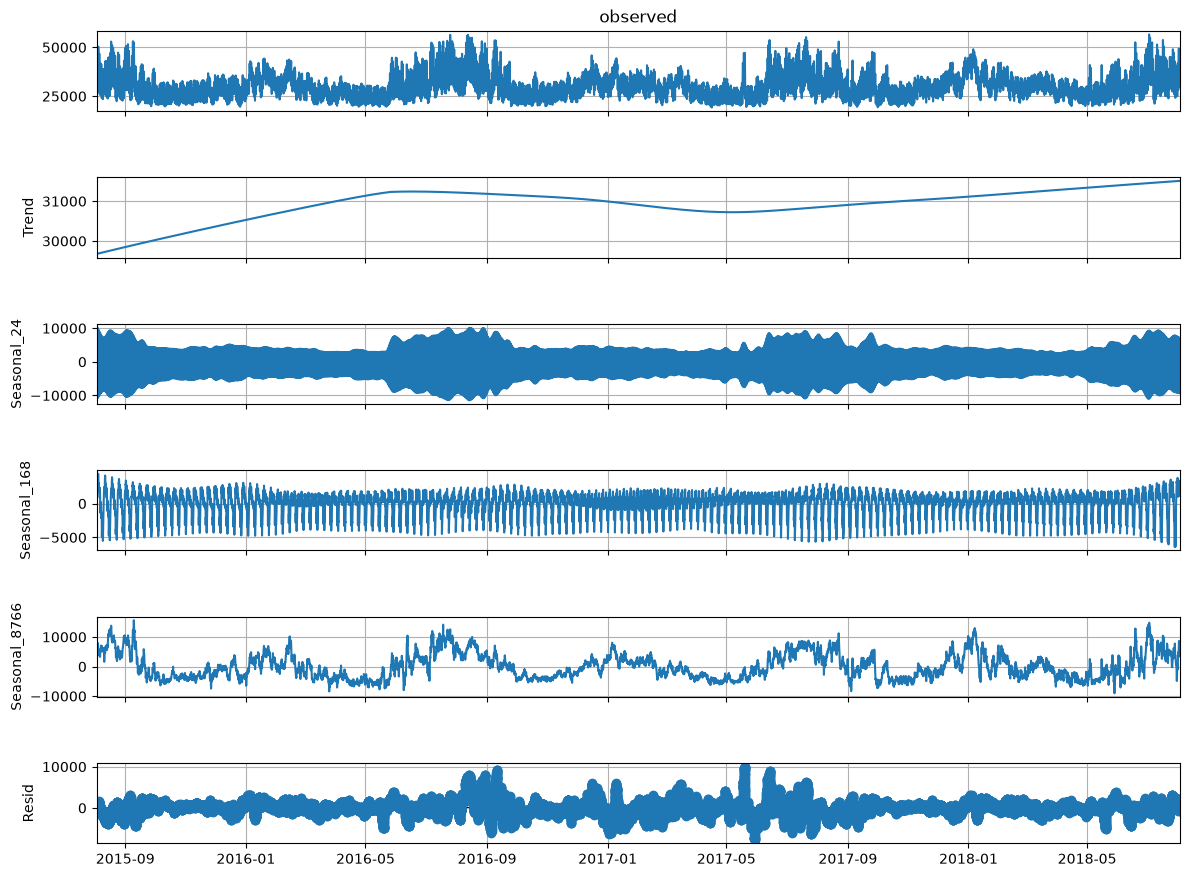

In [36]:
res_mstl_y.plot()
plt.gcf().set_size_inches(12, 10);

Одна неделя крупным планом:

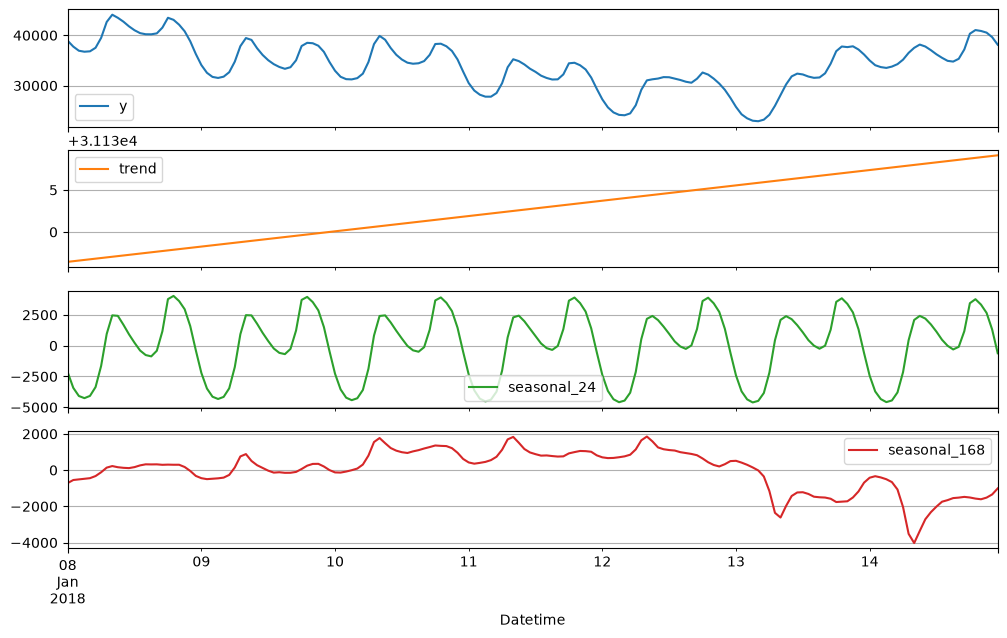

In [37]:
week = slice("2018-01-08", "2018-01-14")
pd.concat([pjme.rename("y"), res_mstl_y.trend, res_mstl_y.seasonal[["seasonal_24", "seasonal_168"]]], axis=1)[week].plot(
    subplots=True, figsize=(12, 7)
);

Дневная сезонность меняется в течение года: heatmap «час × день» за последний год.
Летом — пик днём, зимой — утренний и вечерний.

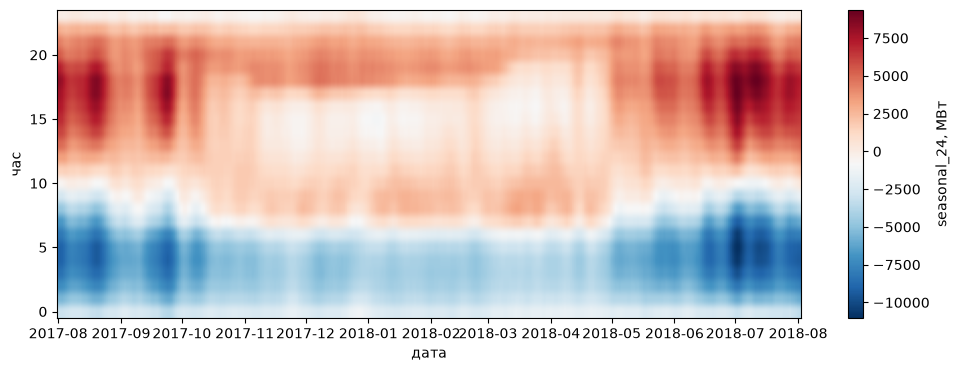

In [38]:
s24 = res_mstl_y.seasonal["seasonal_24"]["2017-08-01":]
heat = s24.groupby([s24.index.hour, s24.index.date]).first().unstack()

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(heat, aspect="auto", cmap="RdBu_r", origin="lower")
xt = [i for i, d in enumerate(heat.columns) if d.day == 1]
ax.set(xticks=xt, xticklabels=[heat.columns[i].strftime("%Y-%m") for i in xt], xlabel="дата", ylabel="час")
ax.grid(False)
fig.colorbar(im, label="seasonal_24, МВт");

Недельный профиль: будни против выходных.

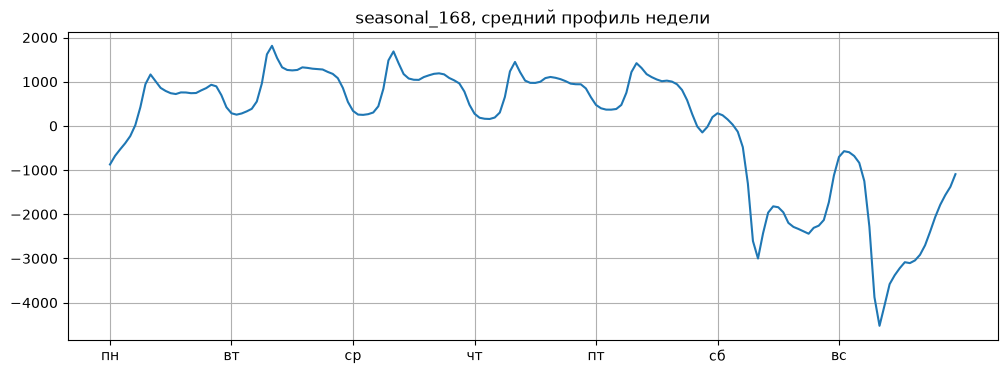

In [39]:
s168 = res_mstl_y.seasonal["seasonal_168"]
weekly = s168.groupby([s168.index.dayofweek, s168.index.hour]).mean()
ax = weekly.reset_index(drop=True).plot(title="seasonal_168, средний профиль недели")
ax.set_xticks(range(0, 168, 24), ["пн", "вт", "ср", "чт", "пт", "сб", "вс"]);

### MSTL в statsforecast

`statsforecast.models.MSTL` — то же разложение. Отличия:
- в STL по умолчанию передаётся `seasonal_deg=0` (как в R `forecast::mstl`);
- нет Box-Cox;
- есть `trend_forecaster` — модель для прогноза тренда (часть 2).

С одинаковыми параметрами результаты совпадают:

In [40]:
sf_comp = SFMSTL(season_length=[24, 168]).fit(pjme.values).model_
sm_comp = MSTL(pjme, periods=[24, 168], stl_kwargs={"seasonal_deg": 0}).fit()
print("trend:      ", np.abs(sf_comp["trend"].values - sm_comp.trend.values).max())
print("seasonal24: ", np.abs(sf_comp["seasonal24"].values - sm_comp.seasonal["seasonal_24"].values).max())
sf_comp.head()

trend:       0.0
seasonal24:  0.0


,data,trend,seasonal24,seasonal168,remainder
0,32928.0,37897.988235,-3036.352004,-1291.836348,-641.799883
1,30290.0,37867.994438,-5714.576813,-1080.495455,-782.922170
2,28490.0,37838.047073,-7557.504033,-908.275511,-882.267529
3,27348.0,37808.146697,-8765.188401,-748.188627,-946.769669
4,26805.0,37778.293902,-9475.806228,-564.838100,-932.649574


В формате statsforecast (`unique_id, ds, y`) разложение даёт `mstl_decomposition`:
компоненты на истории и их продолжение на горизонт `h` (пригодится как признаки во 2-й части).

In [41]:
df = pjme.rename("y").rename_axis("ds").reset_index().assign(unique_id="PJME")
train_df, future_df = mstl_decomposition(df, SFMSTL(season_length=[24, 168]), freq="h", h=24)
train_df.tail(3)

,ds,y,unique_id,trend,seasonal24,seasonal168
26301,2018-08-02 21:00:00,43256.0,PJME,36123.355902,4273.007821,1856.185037
26302,2018-08-02 22:00:00,41552.0,PJME,36130.176480,2781.369472,1677.183578
26303,2018-08-02 23:00:00,38500.0,PJME,36137.113647,-69.005154,1358.150727


In [42]:
future_df.head(3)

,unique_id,ds,trend,seasonal24,seasonal168
0,PJME,2018-08-03 00:00:00,37222.787741,-2831.439590,849.652999
1,PJME,2018-08-03 01:00:00,37234.733907,-5318.975483,659.085554
2,PJME,2018-08-03 02:00:00,37244.509677,-7057.166469,545.764481


## 5. Итоги

| | Классическая | STL | MSTL |
|---|---|---|---|
| Тренд | $2\times m$-MA | LOESS (`trend`) | LOESS из последнего STL |
| Сезонность | среднее по фазе, постоянная | LOESS по подрядам, меняется | несколько STL по очереди |
| Края ряда | NaN | есть | есть |
| Выбросы | сдвигают сезонность во всех периодах | `robust=True` | `stl_kwargs={"robust": True}` |
| Мультипликативность | `model="multiplicative"` | через $\log$ / Box-Cox | `lmbda` |
| Несколько сезонностей | нет | нет | да |
| Главные гиперпараметры | `period`, `model` | `seasonal`, `trend`, `robust` | `periods`, `windows`, `lmbda` |

**Проверка разложения:** в ACF остатка не должно быть пиков на лагах $m, 2m, \dots$.
Если пик есть — сезонность не извлечена. Пример: MSTL только с периодом 24 оставляет в остатке недельный цикл.

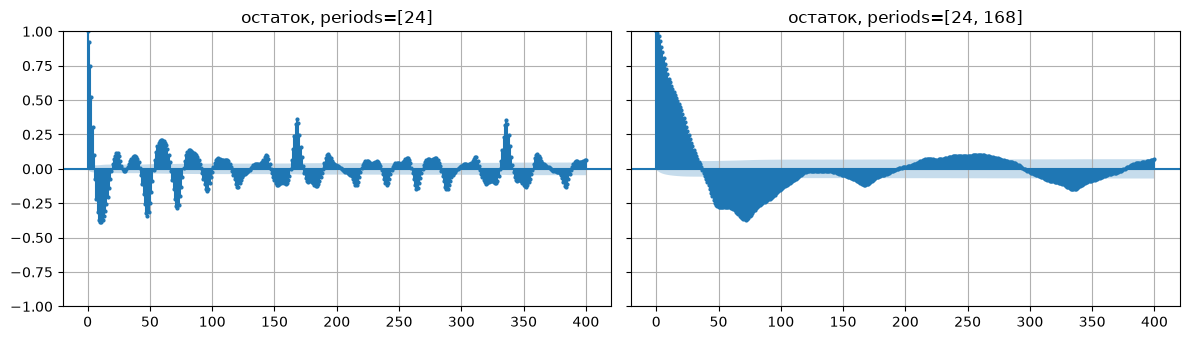

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
plot_acf(MSTL(pjme, periods=[24]).fit().resid, lags=400, ax=axes[0], title="остаток, periods=[24]", markersize=2)
plot_acf(res_mstl.resid, lags=400, ax=axes[1], title="остаток, periods=[24, 168]", markersize=2)
fig.tight_layout()

Пики на 168 и 336 исчезли. Оставшаяся плавная автокорреляция — погода:
декомпозиция не обязана делать остаток белым шумом.